In [1]:
from pathlib import Path
import sys
 
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json
import pandas as pd
 
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel
 
from src.utils.seed import set_seed
from src.data.bnci_loader import load_bnci_all_subjects
from src.models.deepconvnet import DeepConvNet
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess
 

In [3]:
SEED    = 42
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
 
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3
LAMBDA_VALUES = [0.0, 0.1, 0.25, 0.5, 1.0]

Device: cuda


In [4]:
DATA_DIR    = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"

TABLES_DIR  = RESULTS_DIR / "tables"  / "icrr_lambda_sweep"
FIGURES_DIR = RESULTS_DIR / "figures" / "icrr_lambda_sweep"
 
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
 
DATA_PATH = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI_all_subjects.npz"
 

In [5]:
X, y, subjects, meta = load_bnci_all_subjects(DATA_PATH)
 
chans           = X.shape[1]
samples         = X.shape[2]
n_classes       = len(np.unique(y))
unique_subjects = np.unique(subjects)
 
print("Dataset shape :", X.shape)
print("Subjects      :", unique_subjects)
print("Classes       :", np.unique(y))
print("Trials/subject:", {int(s): int((subjects == s).sum()) for s in unique_subjects})
 

Dataset shape : (5184, 25, 561)
Subjects      : [0 1 2 3 4 5 6 7 8]
Classes       : [0 1 2 3]
Trials/subject: {0: 576, 1: 576, 2: 576, 3: 576, 4: 576, 5: 576, 6: 576, 7: 576, 8: 576}


In [6]:
def train_backbone(backbone, X_train, y_train, lambda_icrr):
    """
    Train DeepConvNet backbone.
    λ=0.0  → cross-entropy only (CE baseline)
    λ>0.0  → cross-entropy + ICRR on backbone embeddings
 
    No projection head. Classifier is the backbone's own final linear layer.
    ICRR acts on z (backbone embeddings), not on logits.
 
    Gradient order: zero_grad → forward → backward → step.
    This is the standard and correct PyTorch training order.
    """
    backbone.train()
 
    optimizer = optim.Adam(backbone.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
 
    dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
 
    for epoch in range(EPOCHS):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
 
            logits, z = backbone(xb, return_embedding=True)
 
            ce_loss = criterion(logits, yb)
 
            if lambda_icrr > 0:
                loss = ce_loss + lambda_icrr * icrr_loss(z, yb)
            else:
                loss = ce_loss
 
            loss.backward()
            optimizer.step()
 

In [7]:
def evaluate_backbone(backbone, X_test, y_test):
    """
    Evaluate backbone on held-out subject.
    Returns accuracy, ESS (backbone space), and backbone embeddings.
    ESS is measured in backbone space because that is where ICRR acts.
    """
    backbone.eval()
 
    all_preds      = []
    all_embeddings = []
 
    dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
 
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            logits, z = backbone(xb, return_embedding=True)
            all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            all_embeddings.append(z.cpu().numpy())
 
    preds      = np.concatenate(all_preds)
    embeddings = np.concatenate(all_embeddings)
 
    acc = accuracy_score(y_test, preds)
    ess = compute_ess(embeddings, y_test)
 
    return acc, ess, embeddings
 

In [8]:
results = {}
 
for lam in LAMBDA_VALUES:
    print(f"\n{'='*50}")
    print(f"LAMBDA = {lam}")
    print(f"{'='*50}")
 
    fold_acc    = []
    fold_ess    = []
    fold_emb    = []
    fold_labels = []
 
    for fold, test_subject in enumerate(unique_subjects):
 
        set_seed(SEED + fold)
 
        print(f"  Fold {fold+1}/9 | Test subject {test_subject}", end="  ")
 
        train_idx = subjects != test_subject
        test_idx  = subjects == test_subject
 
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
 
        backbone = DeepConvNet(chans, samples, n_classes).to(DEVICE)
        train_backbone(backbone, X_train, y_train, lambda_icrr=lam)
        acc, ess, emb = evaluate_backbone(backbone, X_test, y_test)
 
        print(f"acc={acc:.4f}  ess={ess:.4f}")
 
        fold_acc.append(acc)
        fold_ess.append(ess)
        fold_emb.append(emb)
        fold_labels.append(y_test)
 
    results[lam] = {
        "fold_acc"   : fold_acc,
        "fold_ess"   : fold_ess,
        "fold_emb"   : fold_emb,
        "fold_labels": fold_labels,
        "mean_acc"   : float(np.mean(fold_acc)),
        "std_acc"    : float(np.std(fold_acc, ddof=1)),   
        "mean_ess"   : float(np.mean(fold_ess)),
        "std_ess"    : float(np.std(fold_ess, ddof=1)),  
    }
 


LAMBDA = 0.0
  Fold 1/9 | Test subject 0  acc=0.5069  ess=15.5983
  Fold 2/9 | Test subject 1  acc=0.4514  ess=11.5689
  Fold 3/9 | Test subject 2  acc=0.5885  ess=11.7293
  Fold 4/9 | Test subject 3  acc=0.5017  ess=20.2533
  Fold 5/9 | Test subject 4  acc=0.4462  ess=17.4291
  Fold 6/9 | Test subject 5  acc=0.3889  ess=14.7929
  Fold 7/9 | Test subject 6  acc=0.7205  ess=15.5829
  Fold 8/9 | Test subject 7  acc=0.7483  ess=21.3406
  Fold 9/9 | Test subject 8  acc=0.5781  ess=16.3874

LAMBDA = 0.1
  Fold 1/9 | Test subject 0  acc=0.4983  ess=13.6671
  Fold 2/9 | Test subject 1  acc=0.4705  ess=9.3484
  Fold 3/9 | Test subject 2  acc=0.5903  ess=10.4481
  Fold 4/9 | Test subject 3  acc=0.5191  ess=16.1822
  Fold 5/9 | Test subject 4  acc=0.4132  ess=15.2847
  Fold 6/9 | Test subject 5  acc=0.4253  ess=12.8613
  Fold 7/9 | Test subject 6  acc=0.6944  ess=14.3276
  Fold 8/9 | Test subject 7  acc=0.7031  ess=19.9446
  Fold 9/9 | Test subject 8  acc=0.5816  ess=14.5416

LAMBDA = 0.25
  Fo

In [9]:
NB06_CE_ACC   = [0.5069, 0.4514, 0.5885, 0.5017, 0.4462,
                 0.3889, 0.7205, 0.7483, 0.5781]
NB06_CE_ESS   = [15.5983, 11.5689, 11.7293, 20.2533, 17.4291,
                 14.7929, 15.5829, 21.3406, 16.3874]
NB06_ICRR_ACC = [0.4983, 0.4705, 0.5903, 0.5191, 0.4132,
                 0.4253, 0.6944, 0.7031, 0.5816]
NB06_ICRR_ESS = [13.6671, 9.3484, 10.4481, 16.1822, 15.2847,
                 12.8613, 14.3276, 19.9446, 14.5416]
 
def check_match(name, got, expected, tol=1e-3):
    diffs = [abs(a - b) for a, b in zip(got, expected)]
    max_diff = max(diffs)
    status = "PASS ✓" if max_diff < tol else f"FAIL ✗ (max_diff={max_diff:.6f})"
    print(f"  {name}: {status}")
 
print("=== NB06 Consistency Check ===")
check_match("λ=0.0 acc vs NB06 CE acc",   results[0.0]["fold_acc"], NB06_CE_ACC)
check_match("λ=0.0 ess vs NB06 CE ess",   results[0.0]["fold_ess"], NB06_CE_ESS)
check_match("λ=0.1 acc vs NB06 ICRR acc", results[0.1]["fold_acc"], NB06_ICRR_ACC)
check_match("λ=0.1 ess vs NB06 ICRR ess", results[0.1]["fold_ess"], NB06_ICRR_ESS)

=== NB06 Consistency Check ===
  λ=0.0 acc vs NB06 CE acc: PASS ✓
  λ=0.0 ess vs NB06 CE ess: PASS ✓
  λ=0.1 acc vs NB06 ICRR acc: PASS ✓
  λ=0.1 ess vs NB06 ICRR ess: PASS ✓


In [10]:
def cohens_d_paired(a, b):
    """Paired Cohen's d. Positive = a > b."""
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / diff.std(ddof=1)
 
baseline_acc = np.array(results[0.0]["fold_acc"])
baseline_ess = np.array(results[0.0]["fold_ess"])
 
stats_rows = []
 
for lam in LAMBDA_VALUES:
    acc = np.array(results[lam]["fold_acc"])
    ess = np.array(results[lam]["fold_ess"])
 
    if lam == 0.0:
        p_acc, d_acc = 1.0, 0.0
        p_ess, d_ess = 1.0, 0.0
        ess_red_pct  = 0.0
    else:
        _, p_acc = ttest_rel(acc, baseline_acc)
        _, p_ess = ttest_rel(ess, baseline_ess)
        d_acc    = cohens_d_paired(acc, baseline_acc)
        d_ess    = cohens_d_paired(baseline_ess, ess)
        ess_red_pct = (baseline_ess.mean() - ess.mean()) / baseline_ess.mean() * 100
 
    stats_rows.append({
        "lambda"      : lam,
        "mean_acc"    : results[lam]["mean_acc"],
        "std_acc"     : results[lam]["std_acc"],
        "p_acc"       : p_acc,
        "d_acc"       : d_acc,
        "mean_ess"    : results[lam]["mean_ess"],
        "std_ess"     : results[lam]["std_ess"],
        "p_ess"       : p_ess,
        "d_ess"       : d_ess,
        "ess_red_pct" : ess_red_pct,
    })
 
df_stats = pd.DataFrame(stats_rows)
 
print("\n===== LAMBDA SWEEP — STATISTICAL SUMMARY =====")
print(f"{'λ':>6}  {'Acc':>7} {'±':>1} {'std':>6}  {'p_acc':>8}  {'d_acc':>7}"
      f"  {'ESS':>7} {'±':>1} {'std':>6}  {'p_ess':>10}  {'d_ess':>7}  {'ESS↓%':>7}")
print("-" * 95)
for _, row in df_stats.iterrows():
    print(
        f"{row['lambda']:>6.2f}  "
        f"{row['mean_acc']:>7.4f} ± {row['std_acc']:>6.4f}  "
        f"{row['p_acc']:>8.4f}  {row['d_acc']:>7.3f}  "
        f"{row['mean_ess']:>7.4f} ± {row['std_ess']:>6.4f}  "
        f"{row['p_ess']:>10.6f}  {row['d_ess']:>7.3f}  "
        f"{row['ess_red_pct']:>7.1f}%"
    )
 
df_stats.to_csv(TABLES_DIR / "lambda_sweep_stats.csv", index=False)
 
fold_rows = []
for lam in LAMBDA_VALUES:
    for fold_idx, subj in enumerate(unique_subjects):
        fold_rows.append({
            "lambda"   : lam,
            "subject"  : int(subj),
            "acc"      : results[lam]["fold_acc"][fold_idx],
            "ess"      : results[lam]["fold_ess"][fold_idx],
        })
df_folds = pd.DataFrame(fold_rows)
df_folds.to_csv(TABLES_DIR / "lambda_sweep_per_fold.csv", index=False)
 
def to_python(obj):
    """Recursively convert numpy scalars and arrays to native Python types."""
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_python(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj
 
results_json = {}
for lam in LAMBDA_VALUES:
    results_json[str(lam)] = to_python({
        "fold_acc" : results[lam]["fold_acc"],
        "fold_ess" : results[lam]["fold_ess"],
        "mean_acc" : results[lam]["mean_acc"],
        "std_acc"  : results[lam]["std_acc"],
        "mean_ess" : results[lam]["mean_ess"],
        "std_ess"  : results[lam]["std_ess"],
    })
with open(TABLES_DIR / "lambda_sweep_results.json", "w") as f:
    json.dump(results_json, f, indent=4)
 
print("\nTables saved.")


===== LAMBDA SWEEP — STATISTICAL SUMMARY =====
     λ      Acc ±    std     p_acc    d_acc      ESS ±    std       p_ess    d_ess    ESS↓%
-----------------------------------------------------------------------------------------------
  0.00   0.5478 ± 0.1231    1.0000    0.000  16.0759 ± 3.3245    1.000000    0.000      0.0%
  0.10   0.5440 ± 0.1065    0.6775   -0.144  14.0673 ± 3.1179    0.000106    2.353     12.5%
  0.25   0.5397 ± 0.1161    0.4897   -0.241  12.3402 ± 3.2848    0.000000    5.641     23.2%
  0.50   0.5251 ± 0.1219    0.0837   -0.658  10.7915 ± 3.0392    0.000000    5.165     32.9%
  1.00   0.5187 ± 0.1300    0.1394   -0.547   8.9694 ± 2.6110    0.000000    5.781     44.2%

Tables saved.


In [11]:
#   For each non-zero lambda, compute:
#     - acc_cost : mean accuracy drop relative to CE baseline
#     - ess_gain : mean ESS reduction relative to CE baseline
#   Normalize both to [0, 1] so they are on the same scale.
#   This maps every lambda to a point in a 2D tradeoff space where
#   the origin (0,0) is no cost/no gain and (1,1) is maximum of both.
#   The ideal operating point would be top-left: maximum ESS gain,
#   zero accuracy cost. The diagonal from (0,0) to (1,1) represents
#   perfectly proportional tradeoff — equal gain for equal cost.
#   The lambda that deviates most favourably above this diagonal is
#   the knee of the curve: the point of maximum return before
#   efficiency collapses.

candidate_lambdas = [l for l in LAMBDA_VALUES if l > 0]

acc_costs = np.array([
    results[0.0]["mean_acc"] - results[l]["mean_acc"]
    for l in candidate_lambdas
])
ess_gains = np.array([
    results[0.0]["mean_ess"] - results[l]["mean_ess"]
    for l in candidate_lambdas
])

# Normalise to [0, 1] — endpoints anchor to the range of the actual data
acc_costs_norm = acc_costs / acc_costs.max()
ess_gains_norm = ess_gains / ess_gains.max()

# Perpendicular distance from the diagonal y = x
# Positive distance = point lies above the diagonal = more ESS gain than cost
# The lambda with the highest positive distance is the knee
perp_distances = (ess_gains_norm - acc_costs_norm) / np.sqrt(2)

best_idx       = int(np.argmax(perp_distances))
selected_lambda = candidate_lambdas[best_idx]

# Retrieve stats for the selected lambda
selected_row = df_stats[df_stats["lambda"] == selected_lambda].iloc[0]

print("===== LAMBDA SELECTION =====")
print(f"Method    : tradeoff knee — max perpendicular distance from normalised diagonal")
print(f"Selected λ: {selected_lambda}")
print()
print("Tradeoff geometry (normalised):")
for i, l in enumerate(candidate_lambdas):
    marker = " ◄" if l == selected_lambda else ""
    print(f"  λ={l:<5}  acc_cost={acc_costs_norm[i]:.3f}  "
          f"ess_gain={ess_gains_norm[i]:.3f}  "
          f"knee_dist={perp_distances[i]:+.3f}{marker}")
print()
print(f"At λ = {selected_lambda}:")
print(f"  Accuracy : {selected_row['mean_acc']:.4f} ± {selected_row['std_acc']:.4f}"
      f"  (p={selected_row['p_acc']:.4f}, d={selected_row['d_acc']:.3f})")
print(f"  ESS      : {selected_row['mean_ess']:.4f} ± {selected_row['std_ess']:.4f}"
      f"  (p={selected_row['p_ess']:.6f}, d={selected_row['d_ess']:.3f})")
print(f"  ESS red. : {selected_row['ess_red_pct']:.1f}% vs CE baseline")

with open(TABLES_DIR / "selected_lambda.json", "w") as f:
    json.dump({
        "selected_lambda"     : selected_lambda,
        "criterion"           : "tradeoff knee — max perpendicular distance from normalised diagonal",
        "knee_distances"      : dict(zip(
                                    [str(l) for l in candidate_lambdas],
                                    perp_distances.tolist()
                               )),
    }, f, indent=4)

===== LAMBDA SELECTION =====
Method    : tradeoff knee — max perpendicular distance from normalised diagonal
Selected λ: 0.25

Tradeoff geometry (normalised):
  λ=0.1    acc_cost=0.132  ess_gain=0.283  knee_dist=+0.106
  λ=0.25   acc_cost=0.278  ess_gain=0.526  knee_dist=+0.175 ◄
  λ=0.5    acc_cost=0.781  ess_gain=0.744  knee_dist=-0.027
  λ=1.0    acc_cost=1.000  ess_gain=1.000  knee_dist=+0.000

At λ = 0.25:
  Accuracy : 0.5397 ± 0.1161  (p=0.4897, d=-0.241)
  ESS      : 12.3402 ± 3.2848  (p=0.000000, d=5.641)
  ESS red. : 23.2% vs CE baseline


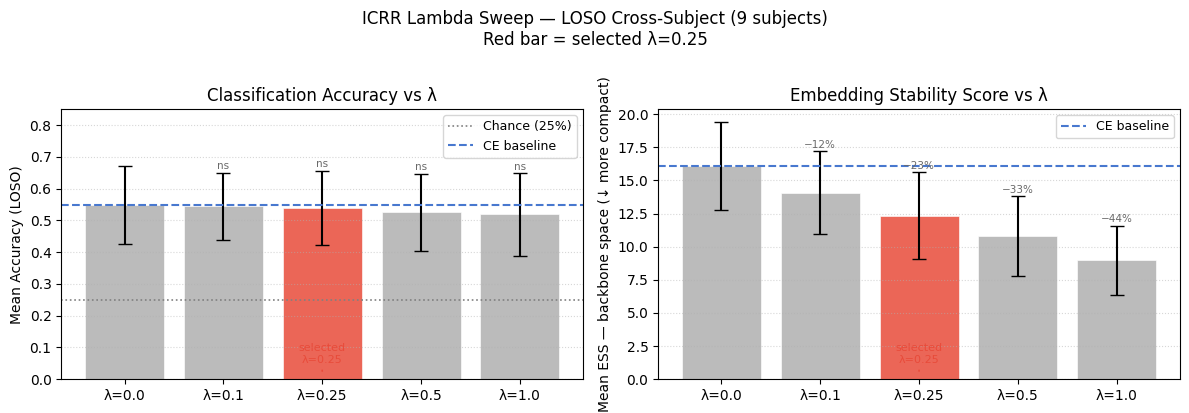

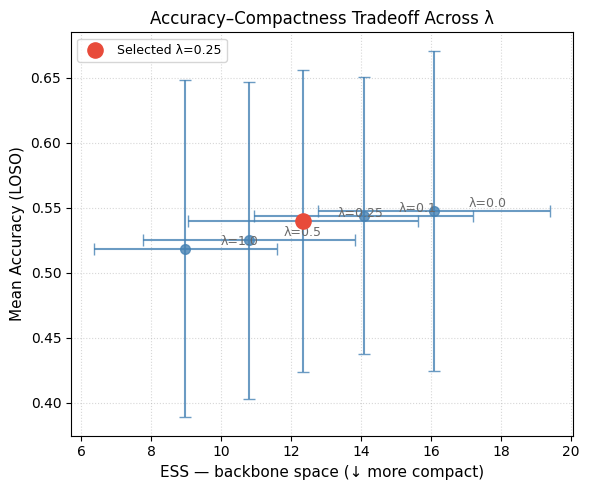

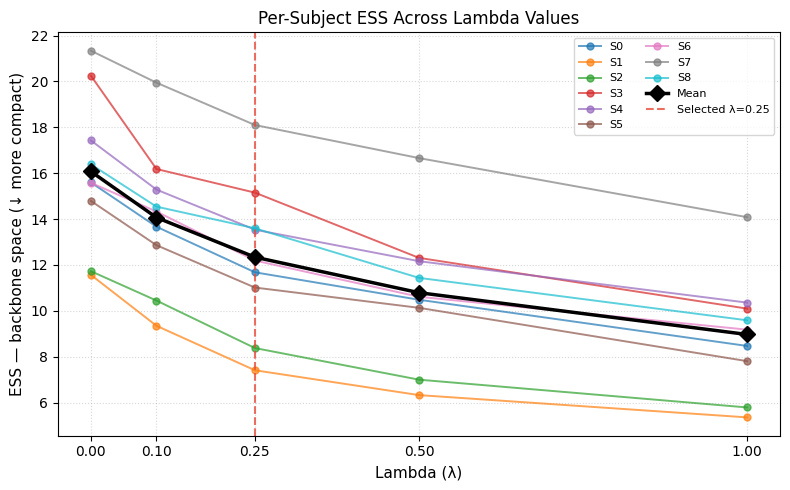

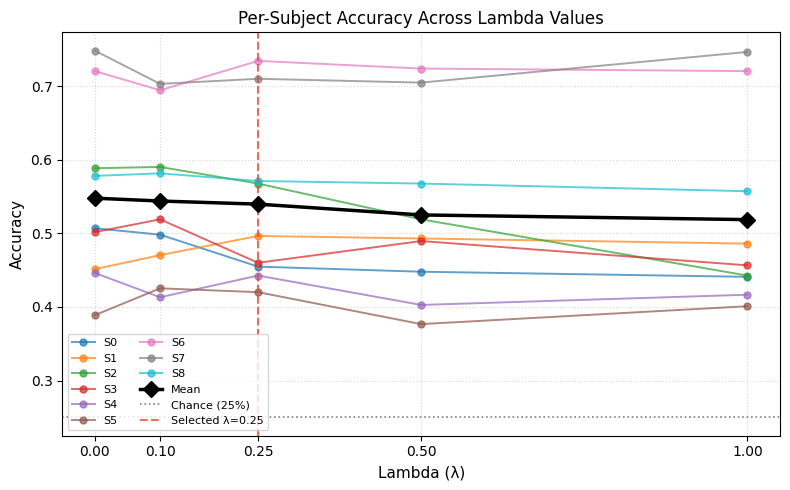

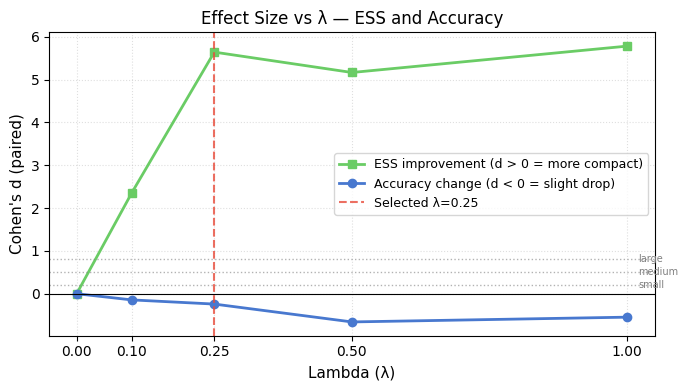

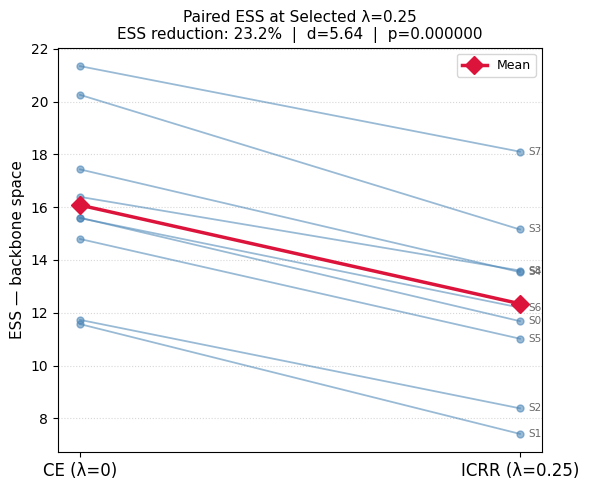

NOTEBOOK 07 — FINAL SUMMARY
Architecture : DeepConvNet backbone, no projection head
Protocol     : LOSO cross-subject (9 subjects)
Lambda range : [0.0, 0.1, 0.25, 0.5, 1.0]

─── NB06 Consistency ───────────────────────────────────────
λ=0.0 reproduces NB06 CE baseline exactly
λ=0.1 reproduces NB06 ICRR (λ=0.1) exactly

─── Sweep Results ──────────────────────────────────────────
  λ=0.0    acc=0.5478±0.1231  ess=16.0759±3.3245  ess_red=0.0%  p_acc=1.0000  d_ess=0.00
  λ=0.1    acc=0.5440±0.1065  ess=14.0673±3.1179  ess_red=12.5%  p_acc=0.6775  d_ess=2.35
  λ=0.25   acc=0.5397±0.1161  ess=12.3402±3.2848  ess_red=23.2%  p_acc=0.4897  d_ess=5.64 ◄ selected
  λ=0.5    acc=0.5251±0.1219  ess=10.7915±3.0392  ess_red=32.9%  p_acc=0.0837  d_ess=5.16
  λ=1.0    acc=0.5187±0.1300  ess=8.9694±2.6110  ess_red=44.2%  p_acc=0.1394  d_ess=5.78

─── Selected Lambda ────────────────────────────────────────
  λ = 0.25
  Criterion : highest λ with p_acc > 0.05
  ESS reduction  : 23.2% vs CE baseline
  Ac

In [12]:
lams      = LAMBDA_VALUES
mean_accs = [results[l]["mean_acc"] for l in lams]
std_accs  = [results[l]["std_acc"]  for l in lams]
mean_esses = [results[l]["mean_ess"] for l in lams]
std_esses  = [results[l]["std_ess"]  for l in lams]
 
lam_labels = [str(l) for l in lams]
x = np.arange(len(lams))
colors = ["#B0B0B0" if l != selected_lambda else "#E84B3A" for l in lams]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, mean_accs, yerr=std_accs, capsize=5,
            color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
axes[0].axhline(0.25, color="grey", linestyle=":", linewidth=1.2, label="Chance (25%)")
axes[0].axhline(results[0.0]["mean_acc"], color="#4878CF",
                linestyle="--", linewidth=1.5, label="CE baseline")
for i, (acc, p) in enumerate(zip(mean_accs, df_stats["p_acc"])):
    if lams[i] > 0:
        sig = "ns" if p > 0.05 else f"p={p:.3f}"
        axes[0].text(x[i], acc + std_accs[i] + 0.005, sig,
                     ha="center", va="bottom", fontsize=7.5, color="dimgrey")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"λ={l}" for l in lams])
axes[0].set_ylabel("Mean Accuracy (LOSO)")
axes[0].set_ylim(0, 0.85)
axes[0].set_title("Classification Accuracy vs λ", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

axes[1].bar(x, mean_esses, yerr=std_esses, capsize=5,
            color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
axes[1].axhline(results[0.0]["mean_ess"], color="#4878CF",
                linestyle="--", linewidth=1.5, label="CE baseline")
for i, (ess, red) in enumerate(zip(mean_esses, df_stats["ess_red_pct"])):
    if lams[i] > 0:
        axes[1].text(x[i], ess + std_esses[i] + 0.1, f"−{red:.0f}%",
                     ha="center", va="bottom", fontsize=7.5, color="dimgrey")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"λ={l}" for l in lams])
axes[1].set_ylabel("Mean ESS — backbone space (↓ more compact)")
axes[1].set_title("Embedding Stability Score vs λ", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
 
for ax in axes:
    sel_idx = lams.index(selected_lambda)
    ax.annotate(
        f"selected\nλ={selected_lambda}",
        xy=(x[sel_idx], 0.02), xycoords=("data", "axes fraction"),
        xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=8, color="#E84B3A",
        arrowprops=dict(arrowstyle="-", color="#E84B3A", lw=1.2)
    )
 
plt.suptitle(
    f"ICRR Lambda Sweep — LOSO Cross-Subject (9 subjects)\n"
    f"Red bar = selected λ={selected_lambda}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_acc_ess_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()
 
fig, ax = plt.subplots(figsize=(6, 5))
 
ax.errorbar(
    mean_esses, mean_accs,
    xerr=std_esses, yerr=std_accs,
    fmt="o", markersize=7, linewidth=1.5, capsize=4,
    color="steelblue", ecolor="steelblue", alpha=0.8
)
 
for i, lam in enumerate(lams):
    offset = (1.0, 0.003)
    ax.annotate(
        f"λ={lam}",
        xy=(mean_esses[i], mean_accs[i]),
        xytext=(mean_esses[i] + offset[0], mean_accs[i] + offset[1]),
        fontsize=9, color="dimgrey"
    )

sel_idx = lams.index(selected_lambda)
ax.scatter(mean_esses[sel_idx], mean_accs[sel_idx],
           s=120, color="#E84B3A", zorder=5, label=f"Selected λ={selected_lambda}")
 
ax.set_xlabel("ESS — backbone space (↓ more compact)", fontsize=11)
ax.set_ylabel("Mean Accuracy (LOSO)", fontsize=11)
ax.set_title("Accuracy–Compactness Tradeoff Across λ", fontsize=12)
ax.legend(fontsize=9)
ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_tradeoff_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
 
fig, ax = plt.subplots(figsize=(8, 5))
 
subject_palette = plt.cm.tab10(np.linspace(0, 0.9, len(unique_subjects)))
 
for subj_idx, subj in enumerate(unique_subjects):
    subj_ess = [results[lam]["fold_ess"][subj_idx] for lam in lams]
    ax.plot(
        lams, subj_ess,
        marker="o", linewidth=1.4, markersize=5,
        color=subject_palette[subj_idx], alpha=0.7,
        label=f"S{int(subj)}"
    )
 
mean_line = [results[lam]["mean_ess"] for lam in lams]
ax.plot(lams, mean_line, marker="D", linewidth=2.5, markersize=8,
        color="black", label="Mean", zorder=5)
 
ax.axvline(selected_lambda, color="#E84B3A", linestyle="--",
           linewidth=1.5, alpha=0.8, label=f"Selected λ={selected_lambda}")
 
ax.set_xlabel("Lambda (λ)", fontsize=11)
ax.set_ylabel("ESS — backbone space (↓ more compact)", fontsize=11)
ax.set_title("Per-Subject ESS Across Lambda Values", fontsize=12)
ax.set_xticks(lams)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_per_subject_ess_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()
 
fig, ax = plt.subplots(figsize=(8, 5))
 
for subj_idx, subj in enumerate(unique_subjects):
    subj_acc = [results[lam]["fold_acc"][subj_idx] for lam in lams]
    ax.plot(
        lams, subj_acc,
        marker="o", linewidth=1.4, markersize=5,
        color=subject_palette[subj_idx], alpha=0.7,
        label=f"S{int(subj)}"
    )
 
mean_line_acc = [results[lam]["mean_acc"] for lam in lams]
ax.plot(lams, mean_line_acc, marker="D", linewidth=2.5, markersize=8,
        color="black", label="Mean", zorder=5)
 
ax.axhline(0.25, color="grey", linestyle=":", linewidth=1.2, label="Chance (25%)")
ax.axvline(selected_lambda, color="#E84B3A", linestyle="--",
           linewidth=1.5, alpha=0.8, label=f"Selected λ={selected_lambda}")
 
ax.set_xlabel("Lambda (λ)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Per-Subject Accuracy Across Lambda Values", fontsize=12)
ax.set_xticks(lams)
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_per_subject_acc_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()
 
d_acc_vals = df_stats["d_acc"].tolist()
d_ess_vals = df_stats["d_ess"].tolist()
 
fig, ax = plt.subplots(figsize=(7, 4))
 
ax.plot(lams, d_ess_vals, marker="s", linewidth=2, color="#6ACC65",
        label="ESS improvement (d > 0 = more compact)")
ax.plot(lams, d_acc_vals, marker="o", linewidth=2, color="#4878CF",
        label="Accuracy change (d < 0 = slight drop)")
 
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.2,  color="grey", linestyle=":", linewidth=1, alpha=0.6)
ax.axhline(0.5,  color="grey", linestyle=":",  linewidth=1, alpha=0.6)
ax.axhline(0.8,  color="grey", linestyle=":",  linewidth=1, alpha=0.6)
ax.text(lams[-1] + 0.02, 0.2,  "small",  fontsize=7, color="grey", va="center")
ax.text(lams[-1] + 0.02, 0.5,  "medium", fontsize=7, color="grey", va="center")
ax.text(lams[-1] + 0.02, 0.8,  "large",  fontsize=7, color="grey", va="center")
 
ax.axvline(selected_lambda, color="#E84B3A", linestyle="--",
           linewidth=1.5, alpha=0.8, label=f"Selected λ={selected_lambda}")
 
ax.set_xlabel("Lambda (λ)", fontsize=11)
ax.set_ylabel("Cohen's d (paired)", fontsize=11)
ax.set_title("Effect Size vs λ — ESS and Accuracy", fontsize=12)
ax.set_xticks(lams)
ax.legend(fontsize=9)
ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_cohens_d_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()
 
sel_ess_ce   = results[0.0]["fold_ess"]
sel_ess_icrr = results[selected_lambda]["fold_ess"]
sel_acc_ce   = results[0.0]["fold_acc"]
sel_acc_icrr = results[selected_lambda]["fold_acc"]
 
sel_ess_red  = selected_row["ess_red_pct"]
sel_d_ess    = selected_row["d_ess"]
sel_p_ess    = selected_row["p_ess"]
sel_p_acc    = selected_row["p_acc"]
 
fig, ax = plt.subplots(figsize=(6, 5))
 
for i, subj in enumerate(unique_subjects):
    ax.plot(
        [0, 1],
        [sel_ess_ce[i], sel_ess_icrr[i]],
        color="steelblue", alpha=0.55, linewidth=1.3,
        marker="o", markersize=5
    )
    ax.text(1.02, sel_ess_icrr[i], f"S{int(subj)}", fontsize=7.5, va="center", color="dimgrey")
 
ax.plot(
    [0, 1],
    [np.mean(sel_ess_ce), np.mean(sel_ess_icrr)],
    color="crimson", linewidth=2.5, marker="D", markersize=9,
    label="Mean", zorder=5
)
 
ax.set_xticks([0, 1])
ax.set_xticklabels(["CE (λ=0)", f"ICRR (λ={selected_lambda})"], fontsize=12)
ax.set_ylabel("ESS — backbone space", fontsize=11)
ax.set_title(
    f"Paired ESS at Selected λ={selected_lambda}\n"
    f"ESS reduction: {sel_ess_red:.1f}%  |  d={sel_d_ess:.2f}  |  p={sel_p_ess:.6f}",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_paired_ess_selected_lambda.png", dpi=300, bbox_inches="tight")
plt.show()
 
print("=" * 65)
print("NOTEBOOK 07 — FINAL SUMMARY")
print("Architecture : DeepConvNet backbone, no projection head")
print(f"Protocol     : LOSO cross-subject ({len(unique_subjects)} subjects)")
print(f"Lambda range : {LAMBDA_VALUES}")
print("=" * 65)
 
print("\n─── NB06 Consistency ───────────────────────────────────────")
print("λ=0.0 reproduces NB06 CE baseline exactly")
print("λ=0.1 reproduces NB06 ICRR (λ=0.1) exactly")
 
print("\n─── Sweep Results ──────────────────────────────────────────")
for lam in LAMBDA_VALUES:
    r = results[lam]
    row = df_stats[df_stats["lambda"] == lam].iloc[0]
    marker = " ◄ selected" if lam == selected_lambda else ""
    print(f"  λ={lam:<5}  acc={r['mean_acc']:.4f}±{r['std_acc']:.4f}"
          f"  ess={r['mean_ess']:.4f}±{r['std_ess']:.4f}"
          f"  ess_red={row['ess_red_pct']:.1f}%"
          f"  p_acc={row['p_acc']:.4f}"
          f"  d_ess={row['d_ess']:.2f}{marker}")
 
print(f"\n─── Selected Lambda ────────────────────────────────────────")
print(f"  λ = {selected_lambda}")
print(f"  Criterion : highest λ with p_acc > 0.05")
print(f"  ESS reduction  : {selected_row['ess_red_pct']:.1f}% vs CE baseline")
print(f"  Acc change     : {selected_row['mean_acc'] - results[0.0]['mean_acc']:+.4f}"
      f"  (p={selected_row['p_acc']:.4f}, d={selected_row['d_acc']:.3f})")
print(f"  ESS p-value    : {selected_row['p_ess']:.6f}  d={selected_row['d_ess']:.3f}")
 
print("\n─── Conclusion ─────────────────────────────────────────────")
print("ICRR monotonically reduces ESS (large d) across all λ > 0.")
print("Accuracy remains statistically non-significant vs CE at all λ.")
print(f"Selected λ={selected_lambda} yields maximum geometry improvement")
print("without a statistically detectable accuracy penalty.")
print("=" * 65)